# Analytical IC-enforcing function
To enforce initial conditions (IC) to PINN's, that is, values for all the derivatives of a function $f$ at point $t_0$, we typically multiply the output of the NN by a handcrafted function that respects those conditions. This handcraft is not trivial, especially if the number of IC to enforce is large. We propose a function that cat match any set of IC at $t_0$.

Given the $n$-order 1-dimensional system
\begin{equation}
\begin{cases}
 f(t_0) = a_0\\
 \frac{\partial f(t_0)}{\partial t_0} = a_1\\
 \frac{\partial^2 f(t_0)}{\partial t_0^2} = a_2\\
 ...\\
\end{cases}
\end{equation}
with $t_0, t, a_n \in \mathbb{R}$, $n \in \mathbb{N}$ and $f\in C^{\infty}$.

Borel's lemma (1895) tells that such a function exists: for $a_0, a_1, a_2, ... \in \mathbb{R}$, there exists a $C^{\infty}$ function $f$ such that $f^{(n)}(t_0) = a_n\forall n\in \mathbb{N}$. We design such a function.

Let us try with Taylor expansion:
\begin{equation}
f(x) = f(t_0) + \frac{f'(t_0)}{1!}(t-t_0) + \frac{f''(t_0)}{2!}(t-t_0)^2 + ...
\end{equation}

In [19]:
%loadlibs
import math
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D 
import sympy as smp

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


In [4]:
a = np.array([1, -2, -2])
t0 = 0.0

def term(t, an, t0, n):
    return an / math.factorial(n) * (t - t0) ** n

def g(t, a, t0):
    res = 0
    for i in range(len(a)):
        res += term(t, a[i], t0, i)
    return res

Now, we can constrain a Neural Network to satisfy those constraints:
\begin{equation}
f(t) = g(t) + (t-t_0)^n \text{NN}(t)
\end{equation}
but if $g(t)$ is polynomial, it will dominate the Neural Network for a $t$ large enough.

# This is a major concern

In [5]:
def NN(shape):
    return 2 * (torch.rand(shape) - 0.5)

def f(t, a, t0):
    n = (a.shape[0]+1)
    return g(t, a, t0) + (t-t0)**n * NN(t.shape)

  0%|          | 0/500 [00:00<?, ?it/s]

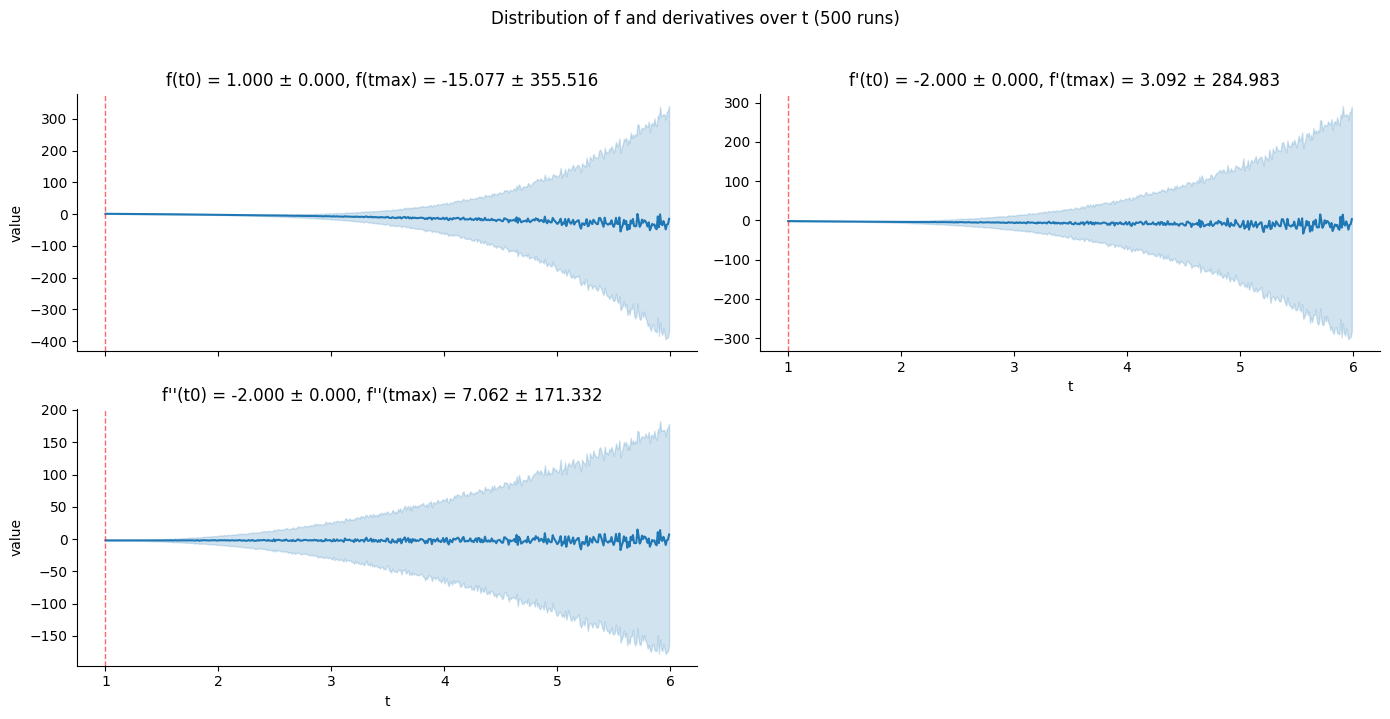

In [6]:
t0, tmax = 1., 5.
t = torch.arange(t0, t0+tmax, 0.01, requires_grad=True)
n_runs = 500
t_np = t.detach().numpy()
t0_idx = np.argmin(np.abs(t_np - t0))

n_derivs = len(a) - 1
deriv_names = ["f"] + [f"f{chr(39) * k}" for k in range(1, n_derivs + 1)] 
ft = f(t, a, t0)
derivs = [ft]
for k in range(n_derivs):
    derivs.append(torch.autograd.grad(derivs[-1], t, torch.ones_like(derivs[-1]), create_graph=True)[0])

idx = (t - t0).abs().argmin().item()

curves_records = []
values_at_t0 = {name: [] for name in deriv_names}
values_at_tmax = {name: [] for name in deriv_names}

for run in tqdm(range(n_runs)):
    ft = f(t, a, t0)
    derivs = [ft]
    for k in range(n_derivs):
        create_graph = (k < n_derivs - 1)
        d = torch.autograd.grad(derivs[-1], t, torch.ones_like(derivs[-1]), create_graph=create_graph)[0]
        derivs.append(d)

    curves = {name: d.detach().numpy() for name, d in zip(deriv_names, derivs)}

    for name, curve in curves.items():
        values_at_t0[name].append(curve[t0_idx])
        values_at_tmax[name].append(curve[-1])
        for ti, vi in zip(t_np, curve):
            curves_records.append({"run": run, "t": ti, "derivative": name, "value": vi})

df = pd.DataFrame(curves_records)
stats_at_t0 = {
    name: (np.mean(vals), np.std(vals))
    for name, vals in values_at_t0.items()
}
stats_at_tmax = {
    name: (np.mean(vals), np.std(vals))
    for name, vals in values_at_tmax.items()
}

n_cols = 2
plots = sns.FacetGrid(df, col="derivative", col_wrap=n_cols, sharex=True, sharey=False, height=3.5, aspect=2, col_order=deriv_names)
plots.map_dataframe(sns.lineplot, x="t", y="value", errorbar="sd")
for ax, name in zip(plots.axes.flat, deriv_names):
    ax.axvline(t0, color="red", linestyle="--", linewidth=1, alpha=0.6)
    mean_val, std_val = stats_at_t0[name]
    mean_val_max, std_val_max = stats_at_tmax[name]
    ax.set_title(f"{name}(t0) = {mean_val:.3f} ± {std_val:.3f}, {name}(tmax) = {mean_val_max:.3f} ± {std_val_max:.3f}  ")
plots.fig.suptitle(f"Distribution of f and derivatives over t ({n_runs} runs)", y=1.02)
plt.tight_layout()
plt.show()

We can clearly see that the function $g$ indeed enforces the conditions, while allowing the Neural network to express many different values. How can we adapt this to higherd-dimensional cases ?
As an example, let us take the $n$-order 2-dimensional system
\begin{equation}
\begin{cases}
 x(t_0) = x_0\\
 y(t_0) = y_0\\
 \frac{\partial x(t_0)}{\partial t_0} = x'_0\\
 \frac{\partial y(t_0)}{\partial t_0} = y'_0\\
 \frac{\partial^2 x(t_0)}{\partial t_0^2} = x''_0\\
 \frac{\partial^2 y(t_0)}{\partial t_0^2} = y''_0\\
 ...\\
\end{cases}
\end{equation}
and, again, with $t_0, t, x_0, y_0, x'_0, y'_0, x''_0, y''_0, ... \in \mathbb{R}$, $m,n \in \mathbb{N}$ and $f\in C^{\infty}$.
To say consistent, we use the matrix a defined as $\begin{pmatrix}
x_0 y_0\\
x'_0 y'_0\\
x''_0 y''_0\\
... ...
\end{pmatrix}$.

We can simply vectorize the Taylor-expansion of the 1-d case. For the first axis, it yields
\begin{equation}
g(t) = \sum_{k=0}^n \frac{x^{(k)})_0}{k!} (t-t_0)^k
\end{equation}

In [7]:
a = torch.tensor(np.array([[1., 1.],
                          [-1., 2.],
                          [0.5, -2]]))
t0 = 0.0

def term(t, a, t0, k):
    return a / math.factorial(k) * (t - t0) ** k

def g(t, a, t0):
    res = torch.zeros((a.shape[-1], t.shape[0]))
    for dim in range(a.shape[-1]):
        for k in range(a.shape[0]):
            res[dim] += term(t, a[k, dim], t0, k)
    return res

t = torch.arange(t0, t0+5, 0.1)
fx, fy = g(t, a, t0)

We can check the derivatives at $t_0$:

In [8]:
n_derivs = len(a) - 1
deriv_names = ["f"] + [f"f{chr(39) * k}" for k in range(1, n_derivs + 1)]

t = torch.arange(t0, t0 + 5, 0.1, requires_grad=True)
ft = g(t, a, t0)

derivs = [ft]

for order in range(n_derivs):
    derivs.append([torch.autograd.grad(derivs[-1][k], t, torch.ones_like(derivs[-1][k]), create_graph=True)[0] for k in range(a.shape[1])])
idx = (t - t0).abs().argmin().item()
for k in range(a.shape[1]):
    vals = [derivs[order][k][idx].item() for order in range(len(derivs))]
    print(f"Component {k}: {dict(zip(deriv_names, vals))}")

Component 0: {'f': 1.0, "f'": -1.0, "f''": 0.5}
Component 1: {'f': 1.0, "f'": 2.0, "f''": -2.0}


And this can be used for constraining any NN:

In [9]:
def f(t, a, t0):
    return g(t, a, t0) + (t - t0) ** (len(a) + 1) * NN((a.shape[-1], t.shape[0]))

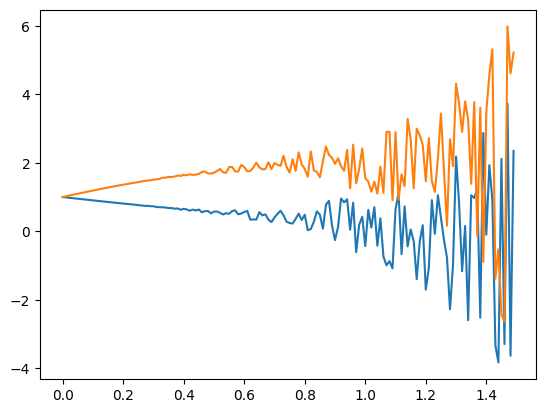

In [10]:
t = torch.arange(t0, t0+1.5, 0.01)
fx, fy = f(t, a, t0)
plt.plot(t, fx)
plt.plot(t, fy)
plt.show()

We can clearly see that the IC function dominates around $t_0$, and lets the Neural Network free for the remaining time.

With a custom **initial condition function** $g_n(t)$ satifying 
```{math} 
:label: eq_condition
    &g_n^{(0)}(0) = f(t_0)\\
    &\vdots \\ 
    &g_n^{(n-1)}(0) = f^{(n-1)}(t_0)
```
We choose for instance $G(t) := \frac{t}{1+t^2}$, and $g_n(t) := \sum_{i=0}^{n-1} A_i G^i(t-t_0)$, then condition {eq}`eq_condition` becomes a linear system of equations
```{math}
    \begin{pmatrix}
        1&G(0)&G^2(0) &\ldots& G^{n-1}(0)\\
        0&G^{(1)}(0) & (G^2)^{(1)}(0) & \ldots & (G^{n-1})^{(1)}(0)\\
        \vdots \\
        0&G^{(n-1)}(0) &(G^2)^{(n-1)}(0) & \ldots &(G^{n-1})^{(n-1)}(0)
    \end{pmatrix} \begin{pmatrix}
    A_0 \\ A_1\\ \vdots \\ A_{n-1}
    \end{pmatrix} = \begin{pmatrix}
        f(t_0)\\ f^{(1)}(t_0) \\ \vdots \\ f^{(n-1)}(t_0)
    \end{pmatrix}
```
that we have to solve for $(A_0,\ldots, A_{n-1})$. 
We then optimise $g_n(t-t_0) + G^n(t-t_0) NN(t)$.

In [89]:
def get_G_term(row, col):
    t = smp.symbols('t')
    G = t/(1+t**2)
    if row == 0:
        dG = G**col
    else:
        dG = G**col
        for _ in range(row):
            dG = smp.diff(dG, t)
    return float(dG.evalf(subs={'t':0}))

In [117]:
def g(t, c_i):
    n = c_i.shape[0]
    G_inv = torch.linalg.inv(torch.tensor(np.array([[get_G_term(i, j) for j in range(n)] for i in range(n)]))).detach().numpy()
    coeffs = torch.tensor(G_inv @ c_i.numpy())
    res = 0
    for i in range(n):
        res += coeffs[i] * (t/(1+t**2))**i
    return res

In [173]:
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(1, 10)
        self.l2 = nn.Linear(10, 1)
        self.activation = nn.Tanh()
        
    def forward(self, x):
        return 10*self.l2(self.activation(self.l1(x)))

def f(t, c_i, t_0):
    NN1 = NN()
    NN2 = NN()
    return g(t-t_0, c_i) + 0.5*(torch.abs(t-t_0)**n/(1+torch.abs(t-t_0)**n) * NN1(t.unsqueeze(-1)).squeeze()) \
    + 0.5*(torch.abs((t-t_0)/2)**n/(1+torch.abs((t-t_0)/2)**n) * NN2(t.unsqueeze(-1)).squeeze())

  0%|          | 0/500 [00:00<?, ?it/s]

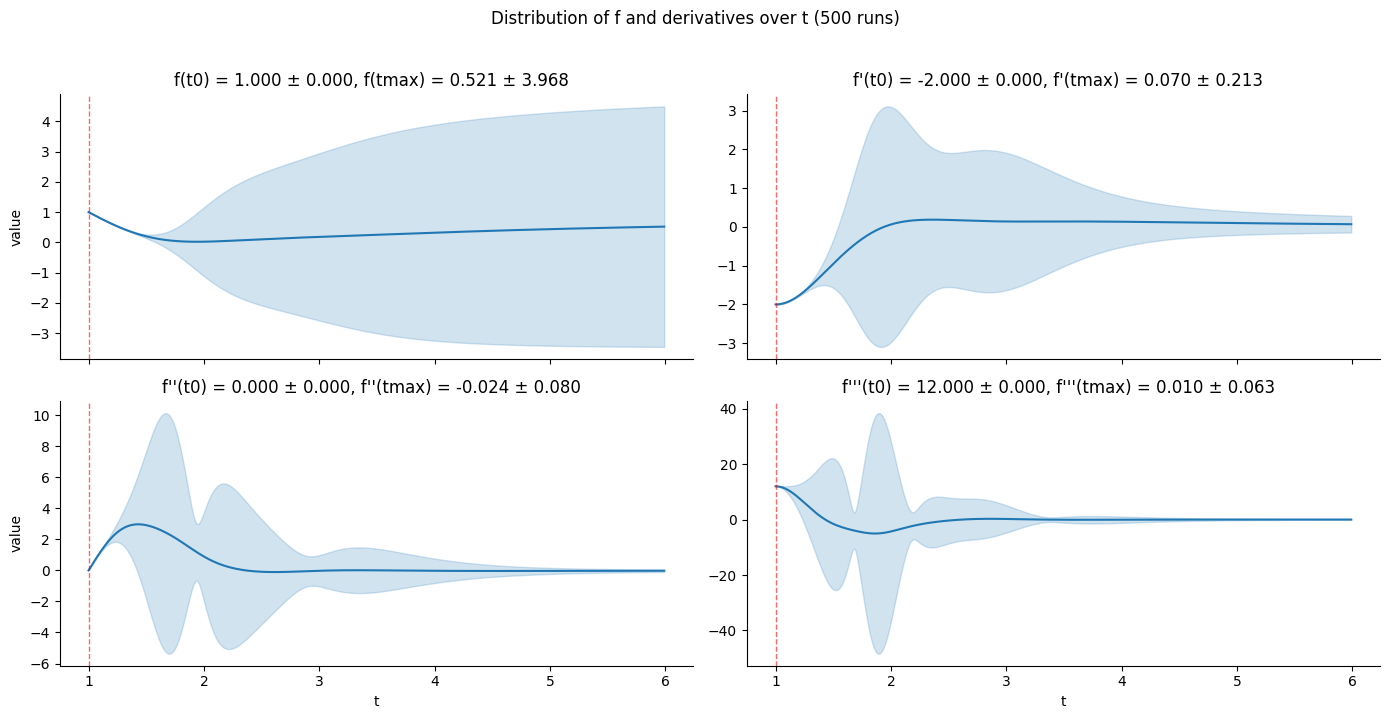

In [174]:
c_i = torch.tensor(np.array([1, -2]))

t0, tmax = 1., 5.
t = torch.arange(t0, t0+tmax, 0.01, requires_grad=True)
n_runs = 500
t_np = t.detach().numpy()
t0_idx = np.argmin(np.abs(t_np - t0))

n_derivs = c_i.shape[0]+1
deriv_names = ["f"] + [f"f{chr(39) * k}" for k in range(1, n_derivs + 1)] 
ft = f(t, c_i, t0)
derivs = [ft]
for k in range(n_derivs):
    derivs.append(torch.autograd.grad(derivs[-1], t, torch.ones_like(derivs[-1]), create_graph=True)[0])

idx = (t - t0).abs().argmin().item()

curves_records = []
values_at_t0 = {name: [] for name in deriv_names}
values_at_tmax = {name: [] for name in deriv_names}

for run in tqdm(range(n_runs)):
    ft = f(t, c_i, t0)
    derivs = [ft]
    for k in range(n_derivs):
        create_graph = (k < n_derivs - 1)
        d = torch.autograd.grad(derivs[-1], t, torch.ones_like(derivs[-1]), create_graph=create_graph)[0]
        derivs.append(d)

    curves = {name: d.detach().numpy() for name, d in zip(deriv_names, derivs)}

    for name, curve in curves.items():
        values_at_t0[name].append(curve[t0_idx])
        values_at_tmax[name].append(curve[-1])
        for ti, vi in zip(t_np, curve):
            curves_records.append({"run": run, "t": ti, "derivative": name, "value": vi})

df = pd.DataFrame(curves_records)
stats_at_t0 = {
    name: (np.mean(vals), np.std(vals))
    for name, vals in values_at_t0.items()
}
stats_at_tmax = {
    name: (np.mean(vals), np.std(vals))
    for name, vals in values_at_tmax.items()
}

n_cols = 2
plots = sns.FacetGrid(df, col="derivative", col_wrap=n_cols, sharex=True, sharey=False, height=3.5, aspect=2, col_order=deriv_names)
plots.map_dataframe(sns.lineplot, x="t", y="value", errorbar="sd")
for ax, name in zip(plots.axes.flat, deriv_names):
    ax.axvline(t0, color="red", linestyle="--", linewidth=1, alpha=0.6)
    mean_val, std_val = stats_at_t0[name]
    mean_val_max, std_val_max = stats_at_tmax[name]
    ax.set_title(f"{name}(t0) = {mean_val:.3f} ± {std_val:.3f}, {name}(tmax) = {mean_val_max:.3f} ± {std_val_max:.3f}  ")
plots.fig.suptitle(f"Distribution of f and derivatives over t ({n_runs} runs)", y=1.02)
plt.tight_layout()
plt.show()

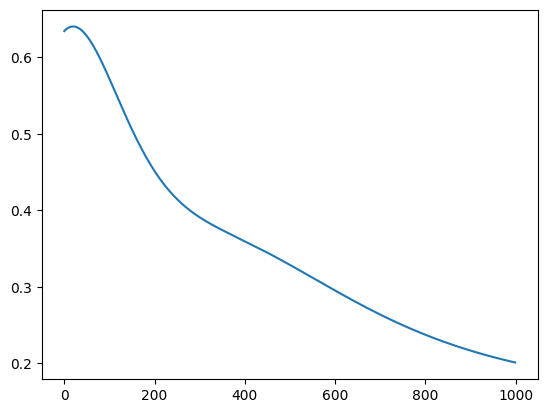

In [167]:
plt.plot(NN2(torch.arange(0, 10, 0.01).unsqueeze(-1)).squeeze().detach())